In [87]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
sf = pd.read_csv('88g8-5mnd_version_709.csv')

In [89]:
sf

,data_loaded_at,hours,employment_type,data_as_of,total_compensation,total_benefits,other_benefits,retirement,job,job_family,...,organization_group_code,total_salary,other_salaries,union_code,overtime,job_family_code,salaries,job_code,health_and_dental,employee_identifier
0,2026-05-11T02:55:21.000,2080.00,Permanent Exempt,2026-05-10T23:27:58.000,10148.76,145.05,145.05,0.00,Superior Court Judge,Untitled,...,1,10003.71,540.12,933.0,0.00,0000,9463.59,990C,0.00,Charles Crompton III
1,2026-05-11T02:55:21.000,2092.00,Permanent Civil Service,2026-05-10T23:27:58.000,117401.58,39356.52,6046.03,17351.39,Medical Evaluations Assistant,"Lab, Pharmacy & Med Techs",...,4,78045.06,2953.74,250.0,699.29,2400,74392.03,2430,15959.10,Hui Tai
2,2026-05-11T02:55:21.000,2080.00,Permanent Civil Service,2026-05-10T23:27:58.000,310543.85,81454.30,12865.52,48041.75,Nurse Practitioner,Nursing,...,4,229089.55,250.00,791.0,0.00,2300,228839.55,2328,20547.03,Karen Triandafyllis
3,2026-05-11T02:55:21.000,2080.00,Permanent Civil Service,2026-05-10T23:27:58.000,169800.91,50150.69,9398.09,24284.06,Sr. Community Devl Spc 1,Community Development,...,6,119650.22,0.00,790.0,0.00,9700,119650.22,9774,16468.54,Anibal Cortez
4,2026-05-11T02:55:21.000,1960.00,Permanent Exempt,2026-05-10T23:27:58.000,186102.74,41698.53,11497.80,30200.73,IS Engineer-Senior,Information Systems,...,3,144404.21,0.00,21.0,0.00,1000,144404.21,1043,0.00,Saroni Ray
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1096097,2026-05-11T02:55:21.000,916.16,Permanent Civil Service,2026-05-10T23:27:58.000,84943.61,24636.13,4942.04,12956.36,Supv Chemist,"Lab, Pharmacy & Med Techs",...,2,60307.48,0.00,21.0,0.00,2400,60307.48,2488,6737.73,Phuong Tran
1096098,2026-05-11T02:55:21.000,2032.00,Permanent Exempt,2026-05-10T23:27:58.000,225505.66,61663.45,11646.33,34762.12,Pharmacist,"Lab, Pharmacy & Med Techs",...,4,163842.21,0.00,790.0,0.00,2400,163842.21,2450,15255.00,John Kapisarov
1096099,2026-05-11T02:55:21.000,2727.25,Permanent Civil Service,2026-05-10T23:27:58.000,178911.29,39289.24,5258.22,18513.19,Deputy Sheriff (SFERS),Correction & Detention,...,1,139622.05,7038.21,498.0,41821.04,8300,90762.80,8504,15517.83,Daniel Gala
1096100,2026-05-11T02:55:21.000,80.00,Permanent Civil Service,2026-05-10T23:27:58.000,16691.46,2335.36,1131.36,616.49,Principal Clerk,"Clerical, Secretarial & Steno",...,2,14356.10,11154.10,790.0,0.00,1400,3202.00,1408,587.51,Emilie Green


In [90]:
sf.describe()

,hours,total_compensation,total_benefits,other_benefits,retirement,year,organization_group_code,total_salary,other_salaries,union_code,overtime,salaries,health_and_dental
count,759886.000000,1.096102e+06,1.096102e+06,1.096102e+06,1.096102e+06,1.096102e+06,1.096102e+06,1.096102e+06,1.096102e+06,1.095921e+06,1.096102e+06,1.096102e+06,1.096102e+06
mean,1722.538596,1.249112e+05,3.268163e+04,5.727355e+03,1.546108e+04,2.019017e+03,2.983303e+00,9.222961e+04,4.277240e+03,4.896092e+02,7.252289e+03,8.070008e+04,1.149320e+04
std,827.024702,8.421718e+04,2.031429e+04,4.008726e+03,1.186815e+04,3.728409e+00,1.580307e+00,6.588254e+04,8.588987e+03,3.298351e+02,1.853543e+04,5.466184e+04,6.837402e+03
min,-536.000000,-7.408261e+04,-2.129515e+04,-1.063650e+04,-3.062143e+04,2.013000e+03,1.000000e+00,-6.877178e+04,-1.913110e+04,1.000000e+00,-4.711391e+04,-6.877178e+04,-3.831090e+03
25%,1200.000000,5.988367e+04,1.583073e+04,2.280952e+03,6.470908e+03,2.016000e+03,2.000000e+00,4.303988e+04,0.000000e+00,2.500000e+02,0.000000e+00,3.926439e+04,5.873140e+03
50%,2080.000000,1.226186e+05,3.622310e+04,5.587340e+03,1.533056e+04,2.019000e+03,2.000000e+00,8.636002e+04,8.927950e+02,5.350000e+02,0.000000e+00,7.805752e+04,1.306798e+04
75%,2156.000000,1.756330e+05,4.566890e+04,8.565817e+03,2.203232e+04,2.022000e+03,4.000000e+00,1.295217e+05,4.983173e+03,7.900000e+02,5.735875e+03,1.148130e+05,1.634682e+04
max,6828.250000,8.700784e+05,2.321588e+05,3.569104e+04,1.964351e+05,2.025000e+03,7.000000e+00,7.431486e+05,3.428026e+05,9.900000e+02,4.872876e+05,6.519367e+05,8.156834e+04


In [91]:
sf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1096102 entries, 0 to 1096101
Data columns (total 26 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   data_loaded_at           1096102 non-null  object 
 1   hours                    759886 non-null   float64
 2   employment_type          759886 non-null   object 
 3   data_as_of               1096102 non-null  object 
 4   total_compensation       1096102 non-null  float64
 5   total_benefits           1096102 non-null  float64
 6   other_benefits           1096102 non-null  float64
 7   retirement               1096102 non-null  float64
 8   job                      1096097 non-null  object 
 9   job_family               1096102 non-null  object 
 10  union                    1095923 non-null  object 
 11  department               1096100 non-null  object 
 12  department_code          1096100 non-null  object 
 13  year_type                1096102 non-null 

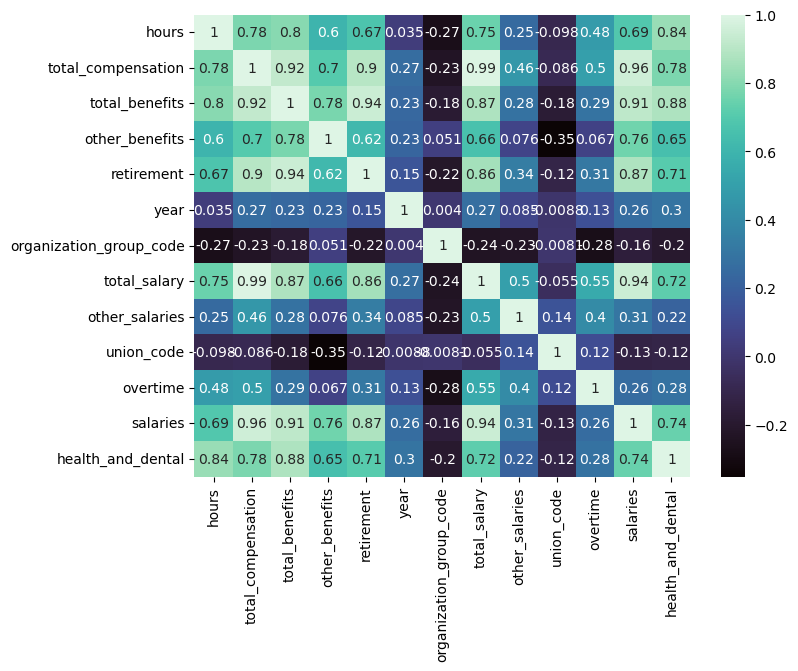

In [92]:
plt.figure(figsize=(8,6))
cols=['hours','total_compensation', 'total_benefits', 'other_benefits',	'retirement', 'year', 'organization_group_code',
      'total_salary', 'other_salaries', 'union_code', 'overtime', 'salaries', 'health_and_dental']
corr=sf[cols].corr()
sns.heatmap(corr, annot=True, cmap='mako')
plt.show()

In [93]:
print(sf[sf['salaries']<0].shape[0])
print(sf[sf['retirement']<0].shape[0])
print(sf[sf['other_salaries']<0].shape[0])
print(sf[sf['overtime']<0].shape[0])
print(sf[sf['health_and_dental']<0].shape[0])
print(sf[sf['hours']<0].shape[0])
print(sf[sf['other_benefits']<0].shape[0])
print(sf[sf['year']<0].shape[0])
print('\n')
print(sf['salaries'].describe())

183
589
177
87
363
95
822
0


count    1.096102e+06
mean     8.070008e+04
std      5.466184e+04
min     -6.877178e+04
25%      3.926439e+04
50%      7.805752e+04
75%      1.148130e+05
max      6.519367e+05
Name: salaries, dtype: float64


In [94]:
sf.shape

(1096102, 26)

In [95]:
sf=sf[
    (sf['salaries']>=0) &
    (sf['retirement']>=0) &
    (sf['other_salaries']>=0) &
    (sf['overtime']>=0) &
    (sf['health_and_dental']>=0) &
    (sf['other_benefits']>=0)
    ]

sf.shape

(1094273, 26)

In [96]:
sf.isnull().sum()

data_loaded_at                  0
hours                      334751
employment_type            334751
data_as_of                      0
total_compensation              0
total_benefits                  0
other_benefits                  0
retirement                      0
job                             5
job_family                      0
union                         179
department                      2
department_code                 2
year_type                       0
year                            0
organization_group              0
organization_group_code         0
total_salary                    0
other_salaries                  0
union_code                    181
overtime                        0
job_family_code                 0
salaries                        0
job_code                        0
health_and_dental               0
employee_identifier             0
dtype: int64

In [97]:
print(sf['job'].nunique())
print(sf['job_family'].nunique())
print(sf['department'].nunique())
print(sf['union'].nunique())
print(sf['organization_group'].nunique())

1409
59
126
129
7


In [98]:
for col in ['job', 'job_family', 'department', 'union', 'organization_group']:
    print(f'{col}: {sf.groupby(col)['salaries'].mean().std():.2f}')

job: 54123.97
job_family: 40755.54
department: 31424.35
union: 62240.68
organization_group: 31409.67


In [123]:
le = LabelEncoder()
for col in ['job_family', 'department', 'union', 'organization_group']:
    sf[col + '_encoded'] = le.fit_transform(sf[col])

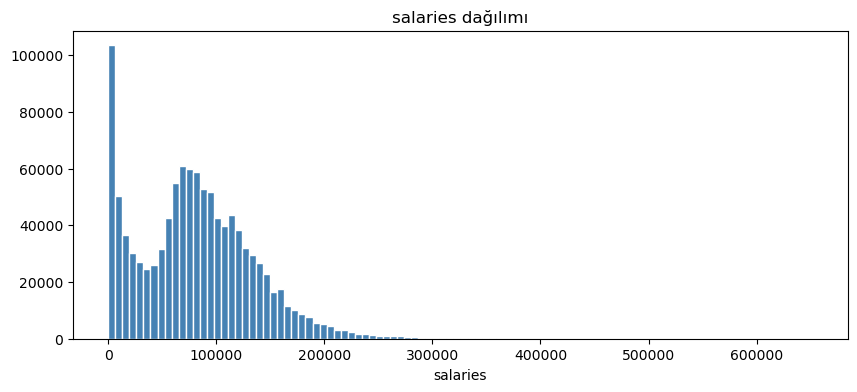

In [100]:
plt.figure(figsize=(10,4))
plt.hist(sf['salaries'], bins = 100, color = 'steelblue', edgecolor = 'white')
plt.title('salaries dağılımı')
plt.xlabel('salaries')
plt.show()

In [ ]:
sf['log_salaries'] = np.log1p(sf['salaries'])
sf[sf['salaries']<1000].shape[0]

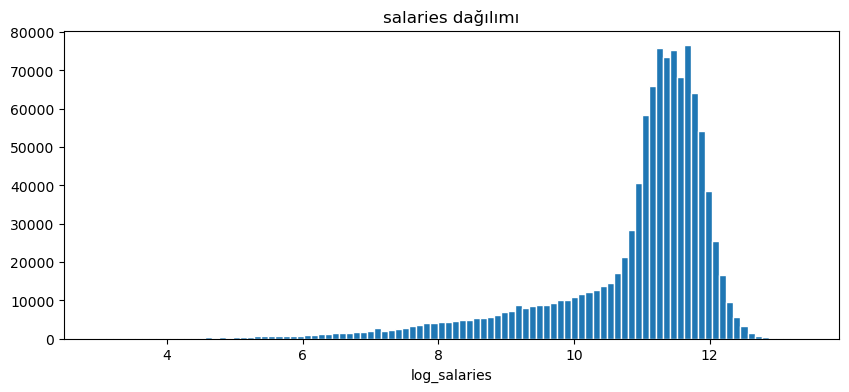

In [102]:
sf = sf[sf['log_salaries']>3]
plt.figure(figsize=(10,4))
plt.hist(sf['log_salaries'], bins = 100, edgecolor = 'white')
plt.title('salaries dağılımı')
plt.xlabel('log_salaries')
plt.show()

In [103]:
print(sf[sf['salaries']<1000]['employment_type'].value_counts())

employment_type
Temporary Exempt           9435
Other                      1376
Permanent Civil Service    1051
Permanent Exempt            780
Temporary Provisional        10
Name: count, dtype: int64


In [104]:
sf['employment_type_encoded'] = le.fit_transform(sf['employment_type'])

In [105]:
sf['hours'] = sf['hours'].fillna(0)

In [106]:
sf.isnull().sum()

data_loaded_at                     0
hours                              0
employment_type               331061
data_as_of                         0
total_compensation                 0
total_benefits                     0
other_benefits                     0
retirement                         0
job                                4
job_family                         0
union                            179
department                         2
department_code                    2
year_type                          0
year                               0
organization_group                 0
organization_group_code            0
total_salary                       0
other_salaries                     0
union_code                       181
overtime                           0
job_family_code                    0
salaries                           0
job_code                           0
health_and_dental                  0
employee_identifier                0
job_family_encoded                 0
d

In [107]:
print(sf['employment_type'].value_counts(dropna=False))

employment_type
Permanent Civil Service    547354
NaN                        331061
Temporary Exempt           132506
Permanent Exempt            60785
Other                        3511
Temporary Provisional        2917
Temporary Civil Service        56
Name: count, dtype: int64


In [108]:
print(sf[sf['employment_type'].isnull()].shape[0])
print(sf[sf['employment_type'].isnull()][['salaries', 'hours', 'year']].describe())

331061
            salaries     hours           year
count  331061.000000  331061.0  331061.000000
mean    64574.011285       0.0    2014.547422
std     44572.286833       0.0       1.116847
min        19.120000       0.0    2013.000000
25%     25650.000000       0.0    2014.000000
50%     63554.950000       0.0    2015.000000
75%     93884.020000       0.0    2016.000000
max    527343.140000       0.0    2016.000000


In [109]:
sf['employment_type'] = sf['employment_type'].fillna('Unknown')
sf['employment_type_encoded'] = le.fit_transform(sf['employment_type'])

In [110]:
features = [
    'hours',
    'other_salaries',
    'health_and_dental',
    'year',
    'job_family_encoded',
    'department_encoded',
    'union_encoded',
    'organization_group_encoded',
    'employment_type_encoded'
]
X = sf[features]
y = sf['log_salaries']
print(X.shape)

(1078190, 9)


In [111]:
X = sf[features]
y = sf['log_salaries']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, y_train.shape)

(862552, 9) (862552,)


In [112]:
!pip install xgboost

In [113]:
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'R2: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')

R2: 0.9588
RMSE: 0.2572


In [114]:
sf.shape

(1078190, 32)

In [115]:
print(sf.groupby('employment_type')['retirement'].mean())
print(sf.groupby('employment_type')['health_and_dental'].mean())

employment_type
Other                       2324.439114
Permanent Civil Service    19422.053770
Permanent Exempt           24398.820153
Temporary Civil Service    10387.852321
Temporary Exempt            3545.001974
Temporary Provisional      10331.365317
Unknown                    13045.317615
Name: retirement, dtype: float64
employment_type
Other                       2797.725440
Permanent Civil Service    14984.513531
Permanent Exempt           15020.754140
Temporary Civil Service    10597.142143
Temporary Exempt            2954.875144
Temporary Provisional      11953.575869
Unknown                     9134.676411
Name: health_and_dental, dtype: float64


In [116]:
print(sf[['salaries', 'other_salaries', 'other_benefits']].corr())

                salaries  other_salaries  other_benefits
salaries         1.00000        0.317440        0.751760
other_salaries   0.31744        1.000000        0.076537
other_benefits   0.75176        0.076537        1.000000


In [117]:
print(X.columns.tolist())
print(X.shape)

['hours', 'other_salaries', 'health_and_dental', 'year', 'job_family_encoded', 'department_encoded', 'union_encoded', 'organization_group_encoded', 'employment_type_encoded']
(1078190, 9)


In [118]:
print(X_train.shape, X_test.shape)

(862552, 9) (215638, 9)


In [119]:
job_family_map = dict(zip(sf['job_family'], sf['job_family_encoded']))
department_map = dict(zip(sf['department'], sf['department_encoded']))
union_map = dict(zip(sf['union'], sf['union_encoded']))
org_map = dict(zip(sf['organization_group'], sf['organization_group_encoded']))
emp_map = dict(zip(sf['employment_type'], sf['employment_type_encoded']))

print(list(job_family_map.items())[:5])
print(list(department_map.items())[:5])
print(list(union_map.items())[:5])
print(list(org_map.items())[:5])
print(list(emp_map.items())[:5])

[('Untitled', 58), ('Lab, Pharmacy & Med Techs', 25), ('Nursing', 33), ('Community Development', 9), ('Information Systems', 23)]
[('Trial Courts', 120), ('Public Health', 97), ('Mayor', 88), ('Homeless Services', 74), ('Recreation And Park Commission', 105)]
[('Court-Judge', 20), ('SEIU, Local 1021, Misc', 98), ('SEIU, Local 1021, RN', 99), ('Prof & Tech Eng, Local 21', 83), ('Electrical Workers, Local 6', 31)]
[('Public Protection', 5), ('Community Health', 0), ('General Administration & Finance', 2), ('Human Welfare & Neighborhood Development', 4), ('Culture & Recreation', 1)]
[('Permanent Exempt', 2), ('Permanent Civil Service', 1), ('Temporary Exempt', 4), ('Other', 0), ('Temporary Provisional', 5)]


In [120]:
print(sf['department'].nunique())
print(sf['department_code'].nunique())
print(sf['job'].nunique())
print(sf['job_code'].nunique())
print(sf['job_family'].nunique())
print(sf['job_family_code'].nunique())
print(sf['union'].nunique())
print(sf['union_code'].nunique())
print(sf['organization_group'].nunique())
print(sf['organization_group_code'].nunique())
print(sf['employment_type'].nunique())
print(sf['year_type'].nunique())

126
62
1407
1254
59
59
129
70
7
7
7
2


In [121]:
import pickle
with open('xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)
with open('mappings.pkl', 'wb') as f:
    pickle.dump({
        'job_family': job_family_map,
        'department': department_map,
        'union': union_map,
        'org': org_map,
        'emp': emp_map
    }, f)
print('Kaydedildi!')

Kaydedildi!


In [122]:
union_code_map = dict(zip(sf['union'], sf['union_code']))
department_code_map = dict(zip(sf['department'], sf['department_code']))
org_code_map = dict(zip(sf['organization_group'], sf['organization_group_code']))
job_family_code_map = dict(zip(sf['job_family'], sf['job_family_code']))
job_code_map = dict(zip(sf['job'], sf['job_code']))

avg_retirement = sf['retirement'].mean()
avg_overtime = sf['overtime'].mean()
avg_other_benefits = sf['other_benefits'].mean()

with open('mappings.pkl', 'wb') as f:
    pickle.dump({
        'job_family': job_family_map,
        'department': department_map,
        'union': union_map,
        'org': org_map,
        'emp': emp_map,
        'union_code': union_code_map,
        'department_code': department_code_map,
        'org_code': org_code_map,
        'job_family_code': job_family_code_map,
        'job_code': job_code_map,
        'avg_retirement': avg_retirement,
        'avg_overtime': avg_overtime,
        'avg_other_benefits': avg_other_benefits
    }, f)

print("Kaydedildi!")

Kaydedildi!
